<a href="https://colab.research.google.com/github/fhzhkunming/ST-554-HW6/blob/main/HW6_Hui_Part_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ST 554 HW#6

Hui Fang

2/28/2026

# Part I - More Practice Querying a Database (16 pts)

There is a database file on the assignment link called `lahman_1871-2022.sqlite` that is an sqlite database
[downloaded from here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.

1. Connect to the database and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a data frame). (2 pts)

In [ ]:
# import module needed
import pandas as pd
import sqlite3

# connect to the database
con = sqlite3.connect('lahman_1871-2022.sqlite')

# SQL query to list all tables
get_table = '''
    SELECT *
    FROM sqlite_schema
    WHERE type='table';
'''
# Return as a dataframe
table_df = pd.read_sql(get_table, con)
table_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


2. Using `SQL`, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the `playerID` and their total (sum) for `GS`, `G`, `W,` `L`, `IPOuts`, `CG`, `SHO`, and `SV` columns. The summing can be done in `pandas` or in the `SQL` call. (6 pts)

In [ ]:
# set the SQL query
get_sum = '''
    SELECT p.playerID, p.GS, p.G, p.W, p.L, p.IPOuts, p.CG, p.SHO, p.SV
    FROM Pitching AS p
    JOIN HallOfFame AS h
        ON p.playerID = h.playerID
    WHERE inducted = 'Y' ;
'''
# converto to a dataframe
sum_df = pd.read_sql(get_sum, con)
# group by 'playerID' to compute sum of those variables
sum_df = sum_df.groupby('playerID').sum()
sum_df

,GS,G,W,L,IPouts,CG,SHO,SV
playerID,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32
ansonca01,0,3,0,1,12,0,0,1
becklja01,1,1,0,1,12,0,0,0
bendech01,334,459,212,127,9051,255,40,34
blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11
wrighge01,0,3,0,1,15,0,0,0
wrighha01,8,36,4,4,301,0,0,14


3. For all of the hall of fame pitchers, use `SQL` to create a table of their batting statistics. Namely, the `playerID` and their total (sum) for `AB`, `R`, `H`, `HR`, `RBI`, `BB`, and `SO`. The summing can be done in `pandas` or in the `SQL` call. (4 pts)

In [ ]:
# set SQL qurey
get_bat = '''
    SELECT b.playerID, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO
    FROM Batting AS b
    JOIN Pitching AS p
        ON b.playerID = p.playerID
    JOIN HallOfFame AS h
        ON b.playerID = h.playerID
    WHERE inducted = 'Y';
'''
# convert to a data frame
bat_df = pd.read_sql(get_bat, con)
# group by 'playerID' to compute sum of target variables
bat_df = bat_df.groupby('playerID').sum()
bat_df

,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,
alexape01,38010,3234,7938,231,3423.0,1617,5796.0
ansonca01,20562,3998,6870,194,4150.0,1968,660.0
becklja01,9551,1603,2938,87,1581.0,616,526.0
bendech01,18352,1632,3888,96,1856.0,1200,2288.0
blylebe01,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...
willivi01,19409,1391,3224,13,1092.0,1053,2587.0
wrighge01,5746,1330,1732,22,652.0,136,238.0
wrighha01,3252,732,896,16,452.0,148,56.0


4. Using `pandas` join the previous two tables together by pitcher. (If you want, try to do all of this via
`SQL`! Not required though, feel free to use `pd.merge()` if you’d like) (4 pts)

In [ ]:
pd.merge(sum_df, bat_df, on='playerID')

,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32,38010,3234,7938,231,3423.0,1617,5796.0
ansonca01,0,3,0,1,12,0,0,1,20562,3998,6870,194,4150.0,1968,660.0
becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
bendech01,334,459,212,127,9051,255,40,34,18352,1632,3888,96,1856.0,1200,2288.0
blylebe01,685,692,287,250,14910,242,60,0,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11,19409,1391,3224,13,1092.0,1053,2587.0
wrighge01,0,3,0,1,15,0,0,0,5746,1330,1732,22,652.0,136,238.0
wrighha01,8,36,4,4,301,0,0,14,3252,732,896,16,452.0,148,56.0


# Part II - Messing with Classes

5. In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample slope. The setup was:

- Recall we assume the following model for SLR:

$$ Y_i = \beta_0 + \beta_1 x_i + E_i $$
where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance $σ^2$. Let's assume $σ^2 = 1$ for simplicity.
- We can generate data from this model by assuming values for $β_0$, $β_1$, and *n*, along with a sequence of *x* values.

Here is code to complete tat part:

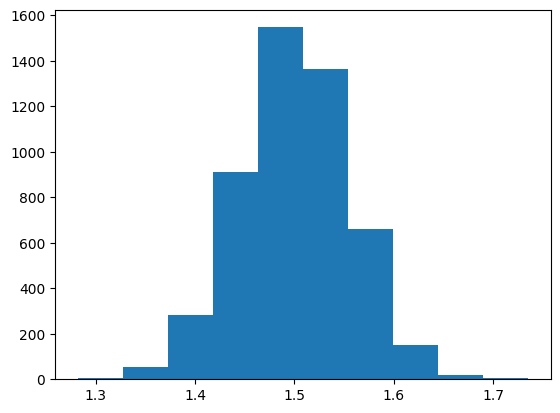

In [ ]:
# import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

# prepare for the LR fit
reg = linear_model.LinearRegression()
# Create a reg object

# initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):
    # create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    # find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

# visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [ ]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

Instead of writing this simulation in this way, we’ll design a Python class that encapsulates the simulation of the sampling distribution of the slope estimator!








  

- Below you definition of your class and its methods, add a section of code that
   – Creates an instance of the object with beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10

   – Call your plot_sampling_distribution() method (this should return the error message)

   – Run 10000 simulations

   – Plot the sampling distribution

   – Approximate the two-sided probability of being larger than 2.1

   – Print out the value of the simulated slopes using the attribute

- Below you definition of your class and its methods, add a section of code that

  – Creates an instance of the object with beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10

  – Call your run_simulation() method (this should return the error message)

  – Run 10000 simulations

  – Plot the sampling distribution

  – Approximate the two-sided probability of being larger than 2.1

  – Print out the value of the simulated slopes using the attribute

Create a class called `SLR_slope_simulator`:

- Initialize the class using `__init__` with arguments `self`, `beta_0`, `beta_1`, x, `sigma`, and `seed`

  – Create initial attributes of beta_0, beta_1, sigma, x, n, rng, and slopes (an empty list)

In [ ]:
"""
SLR_slope_simulator.py

This module defines a class for simulating
the sampling distribution of the slope
estimator in simple linear regression.
"""

# import modules needed
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
import matplotlib.pyplot as plt

class SLR_slope_simulator:
    """
    A class to simulate slope estimates from repeated
    simple linear regression (SLR) fits.
    """
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        # store model parameters
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma

        # store x values and sample size
        self.x = x
        self.n = len(x)

        # set ramdom number generator and seed
        self.rng = default_rng(seed)

        # create an empty list to store slope estimates
        self.slopes = []

- Required Methods. Your class should include methods (not @classmethod, just methods that work on an already created instances of the class):

  – `generate_data` method that generates one dataset (returning x and y in whatever manner you deem fit, i.e. as an array, two arrays, etc.)

In [ ]:
# define a method to generate data
def generate_data(self):
    """
    Generate one dataset (x, y) from the linear model:
    y = beta_0 + beta_1*x + error
    """
    error = self.rng.normal(0, self.sigma, self.n)
    y = self.beta_0 + self.beta_1 * self.x + error
    return self.x, y

  – `fit_slope` method that takes in an x and y and fits the SLR model, returning the estimated slope

In [ ]:
# prepare for the linear regression fit
def fit_slope(self, x, y):
    """
    Fit simple linear regression (SLR) model and return the estimated slope.
    """
    reg = linear_model.LinearRegression()
    reg.fit(x.reshape(-1, 1), y)
    return reg.coef_[0]

 – `run_simulations` method that takes in a number of simulations argument and uses the `generate_data()` and `fit_slope()` methods within a for loop. This should not return anything but should modify the `slopes` attribute (replaces it with an array of slope estimates)

In [ ]:
# run simulations
def run_simulations(self, n_sims):
    """
    Run n_sims simulations and store slopes in self.slope
    """
    self.slopes = [] # reset before running
    for _ in range(n_sims):
        x, y = self.generate_data()
        slope = self.fit_slope(x, y)
        self.slopes.append(slope)


  – `plot_sampling_distribution` method that checks if the `slopes` attribute has length greater than 0 (if it doesn’t print a message that `run_simulations()` must be called first). If it is, it should produce a histogram of the slopes approximating the sampling distribution.

In [ ]:
# define a method to plot sampling slopes
def plot_sampling_distribution(self):
    """
    Plot a histogram of the simulated slope estimates.
    """
    # check if simulations have been run
    if len(self.slopes) > 0:
        plt.hist(self.slopes)
        plt.xlabel("Slope estimates")
        plt.ylabel("Frequency")
        plt.title("Sampling Distribution of the Slope")
        plt.show()
    else:
        print("run_simulations() must be called first!")

– `find_prob` method that takes in a `value` and a `sided` argument. It should checks on the `slopes` attribute as above. If the length is bigger than 0, it should approximate the probability of being “above”, “below”, or “two-sided” (values for `sided`).

   ∗ If sided is “above”, you should approximate the probability of being larger than the value.

   ∗ If it is “below”, you should approximate the probability of being smaller than the value.

   ∗ If it is “two-sided”, you should approximate the probability of being larger in absolute value

In [45]:
# define a method to compute probability based on slope distribution
def find_prob(self, value, sided):
    """
    Compute probability based on slope distribution.

    sided options:
    - "above": P(slope > value)
    - "below": P(slope < value)
    - "two-sided": P(|slope| > |value|)
    """
    # check if simulations have been run
    if len(self.slopes) == 0:
        print("run_simulations() must be called first!")
        return None

    # convert slopes to an np.array
    slopes = np.array(self.slopes)

    if sided == "above":
        prob = np.mean(slopes > value)
    elif sided == "below":
        prob = np.mean(slopes < value)
    elif sided == "two-sided":
        median_val = np.median(slopes)

        if value > median_val:
            prob = 2 * np.mean(slopes > abs(value))
        else:
            prob = 2 * np.mean(slopes < abs(value))
    else:
        raise ValueError("sided must be 'above', 'below', or 'two-sided'")
    return prob

In [46]:
"""
SLR_slope_simulator.py

This module defines a class for simulating
the sampling distribution of the slope
estimator in simple linear regression.
"""

# import modules needed
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
import matplotlib.pyplot as plt

class SLR_slope_simulator:
    """
    A class to simulate slope estimates from repeated
    simple linear regression (SLR) fits.
    """
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        # store model parameters
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma

        # store x values and sample size
        self.x = x
        self.n = len(x)

        # set ramdom number generator and seed
        self.rng = default_rng(seed)

        # create an empty list to store slope estimates
        self.slopes = []

    # define a method to generate data
    def generate_data(self):
        """
        Generate one dataset (x, y) from the linear model:
        y = beta_0 + beta_1*x + error
        """
        error = self.rng.normal(0, self.sigma, self.n)
        y = self.beta_0 + self.beta_1 * self.x + error
        return self.x, y

    # prepare for the linear regression fit
    def fit_slope(self, x, y):
        """
        Fit simple linear regression (SLR) model and return the estimated slope.
        """
        reg = linear_model.LinearRegression()
        reg.fit(x.reshape(-1, 1), y)
        return reg.coef_[0]

    # run simulations
    def run_simulations(self, n_sims):
        """
        Run n_sims simulations and store slopes in self.slope
        """
        self.slopes = [] # reset before running
        for _ in range(n_sims):
            x, y = self.generate_data()
            slope = self.fit_slope(x, y)
            self.slopes.append(slope)

    # define a method to plot sampling slopes
    def plot_sampling_distribution(self):
        """
        Plot a histogram of the simulated slope estimates.
        """
        # check if simulations have been run
        if len(self.slopes) > 0:
            plt.hist(self.slopes)
            plt.xlabel("Slope estimates")
            plt.ylabel("Frequency")
            plt.title("Sampling Distribution of the Slope")
            plt.show()
        else:
            print("run_simulations() must be called first!")

    # define a method to compute probability based on slope distribution
    def find_prob(self, value, sided):
        """
        Compute probability based on slope distribution.

        sided options:
        - "above": P(slope > value)
        - "below": P(slope < value)
        - "two-sided": P(|slope| > |value|)
        """
        # check if simulations have been run
        if len(self.slopes) == 0:
            print("run_simulations() must be called first!")
            return None

        # convert slopes to an np.array
        slopes = np.array(self.slopes)

        if sided == "above":
            prob = np.mean(slopes > value)
        elif sided == "below":
            prob = np.mean(slopes < value)
        elif sided == "two-sided":
            median_val = np.median(slopes)

            if value > median_val:
                prob = 2 * np.mean(slopes > abs(value))
            else:
                prob = 2 * np.mean(slopes < abs(value))
        else:
            raise ValueError("sided must be 'above', 'below', or 'two-sided'")
        return prob

Put the above pieces together to form the entire class

In [ ]:
"""
SLR_slope_simulator.py

This module defines a class for simulating
the sampling distribution of the slope
estimator in simple linear regression.
"""

# import modules needed
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
import matplotlib.pyplot as plt

class SLR_slope_simulator:
    """
    A class to simulate slope estimates from repeated
    simple linear regression (SLR) fits.
    """
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        # store model parameters
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma

        # store x values and sample size
        self.x = x
        self.n = len(x)

        # set ramdom number generator and seed
        self.rng = default_rng(seed)

        # create an empty list to store slope estimates
        self.slopes = []

    # define a method to generate data
    def generate_data(self):
        """
        Generate one dataset (x, y) from the linear model:
        y = beta_0 + beta_1*x + error
        """
        error = self.rng.normal(0, self.sigma, self.n)
        y = self.beta_0 + self.beta_1 * self.x + error
        return self.x, y

    # prepare for the linear regression fit
    def fit_slope(self, x, y):
        """
        Fit simple linear regression (SLR) model and return the estimated slope.
        """
        reg = linear_model.LinearRegression()
        reg.fit(x.reshape(-1, 1), y)
        return reg.coef_[0]

    # run simulations
    def run_simulations(self, n_sims):
        """
        Run n_sims simulations and store slopes in self.slope
        """
        self.slopes = [] # reset before running
        for _ in range(n_sims):
            x, y = self.generate_data()
            slope = self.fit_slope(x, y)
            self.slopes.append(slope)

    # define a method to plot sampling slopes
    def plot_sampling_distribution(self):
        """
        Plot a histogram of the simulated slope estimates.
        """
        # check if simulations have been run
        if len(self.slopes) > 0:
            plt.hist(self.slopes)
            plt.xlabel("Slope estimates")
            plt.ylabel("Frequency")
            plt.title("Sampling Distribution of the Slope")
            plt.show()
        else:
            print("run_simulations() must be called first!")

    # define a method to compute probability based on slope distribution
    def find_prob(self, value, sided):
        """
        Compute probability based on slope distribution.

        sided options:
        - "above": P(slope > value)
        - "below": P(slope < value)
        - "two-sided": P(|slope| > |value|)
        """
        # check if simulations have been run
        if len(self.slopes) == 0:
            print("run_simulations() must be called first!")
            return None

        # convert slopes to an np.array
        slopes = np.array(self.slopes)

        if sided == "above":
            prob = np.mean(slopes > value)
        elif sided == "below":
            prob = np.mean(slopes < value)
        elif sided == "two-sided":
            median_val = np.median(slopes)

            if value > median_val:
                prob = 2 * np.mean(slopes > abs(value))
            else:
                prob = 2 * np.mean(slopes < abs(value))
        else:
            raise ValueError("sided must be 'above', 'below', or 'two-sided'")
        return prob

# Testing the **SLR_slope_simulator** class

- Creates an instance of the object with beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start
= 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10


In [ ]:
# Create an instance of the SLR_slope_simulator object
sim = SLR_slope_simulator(
    beta_0 = 12,
    beta_1 = 2,
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11)) * 3),
    sigma = 1,
    seed = 10)

- Call "plot_sampling_distribution()" before running any simulations to confirm that the method prints the error message.*italicized text*

In [ ]:
# Call plot_sampling_distribution() method with no arguemnt (should produce error message)
# this should print: "run_simulation() must be called first!"
sim.plot_sampling_distribution()

run_simulations() must be called first!


- Then, run **10,000** simulations, plot the sampling distribution of the slope estimated, compute the **two-sided probability** of being larger than **2.1**.

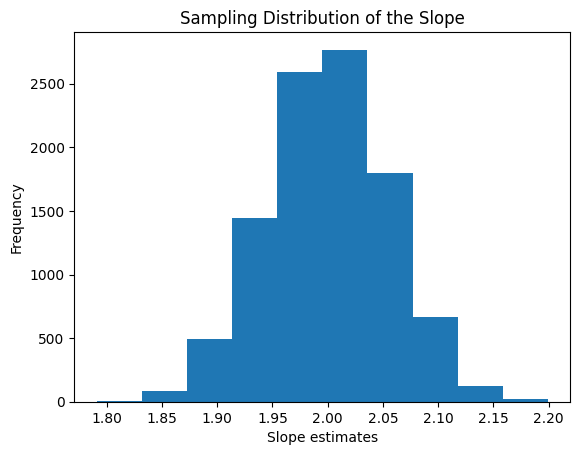

Two-sided probability of |slope| > 2.1 is 0.0704


In [ ]:
# Run 10,000 simulations
sim.run_simulations(10000)

# Plot the sampling distribution
sim.plot_sampling_distribution()

# Approximate the two-sided probability of being larger than 2.1
prob_two_sided = sim.find_prob(2.1, "two-sided")
print("Two-sided probability of |slope| > 2.1 is", prob_two_sided)

- Finally print the full vector of simulated slopes.

In [ ]:
# Print out the first 10 simulated slopes
print(np.array(sim.slopes)[:10])

[2.0239168  1.99560551 2.04249093 1.96489641 2.01114235 1.98626121
 2.03443803 2.08981268 2.01691868 1.91179937]
